In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import healpy as hp
import fitsio
from astropy.table import Table
import scienceplots
plt.style.use(['science','notebook','grid'])
from astropy.table import Table
import fitsio``
import pyccl as ccl
from scipy.optimize import curve_fit as cf


nside=1024
npix= 12*nside**2

In [135]:
def get_mask(ra,dec,nside):
    theta = np.radians(90 -dec)
    phi = np.radians(ra)
    pix = hp.ang2pix(nside, theta, phi)
    mask = np.bincount(pix, minlength=hp.nside2npix(nside))
    mask = np.where(mask>0, 1, 0)
    return mask
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [3]:
table_selection = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/table_match_final.fits')[1].read())
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
RA_data   = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
DEC_data  = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))

In [4]:
north = Table(fitsio.FITS('../../FP_CUTS/table_north_unique.fits')[1].read())
south  = Table(fitsio.FITS('../../FP_CUTS/table_south_unique.fits')[1].read())
ra_north,dec_north = north['RA'], north['DEC']  
ra_south,dec_south = south['RA'], south['DEC']  


In [ ]:
##making a mask



# random_compiled = fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_1.fits')[1].read()
# rand_table=Table(random_compiled)
# rand_table = rand_table[rand_table['DEC'] > -30]
# RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
# RA_random,DEC_random = rand_table['RA'], rand_table['DEC']  
# RA_random = np.ascontiguousarray(np.array(RA_random, dtype=np.float64))
# DEC_random= np.ascontiguousarray(np.array(DEC_random, dtype=np.float64))
# rand_map = points_to_map(RA_random, DEC_random, nside, None)


In [76]:
data_map = points_to_map(RA_data, DEC_data, nside, None)
mask=np.load('../cl_estimate_backup/mask_dense.npy')

In [127]:
tot1=np.sum(mask)
tot2=np.sum(data_map)
fsky=tot1/npix
rntot1=np.copy(tot2)
lmax=1000
nell=10
xx=np.zeros(lmax+1)
nbins=lmax/nell
ll=np.arange(0,lmax+1)

map1=mask*(data_map*tot1/tot2 - 1)
a1=hp.map2alm(map1,lmax=lmax)
#print('Alm\'s:',a1)
p1=hp.alm2cl(a1)

dl1=ll*(ll+1)/2/np.pi*p1/fsky
pshot=2*fsky*ll*(1+ll)/rntot1
# plt.plot(dl1,'.')
# dl1=dl1-pshot
# plt.plot(dl1,'.')


In [81]:
# d1 is an array of CL values for l values from 0 to lmax
# Now we will bin these CL values in bins of size nell=10

In [103]:
bins = np.arange(nell, lmax+nell, nell)
bin_centers= (bins[1:]+bins[:-1])/2
#bin_centers = np.r_[bins[0]/2,bin_centers]
breakpoints=np.arange(nell,len(dl1)-1,nell)+1
#starts = np.r_[0,breakpoints]
sums = np.add.reduceat(dl1, breakpoints)
sumsq = np.add.reduceat(dl1**2, breakpoints)
pshot1 = 2*fsky*bin_centers * (1+bin_centers)/rntot1 
dCl = np.sqrt(sumsq/nell  - (sums**2)/nell**2)/(np.sqrt(fsky))/np.sqrt(nell-1)
Cl = sums/nell - pshot1

Text(0.5, 1.0, 'Angular Power Spectrum of Cleaned Map')

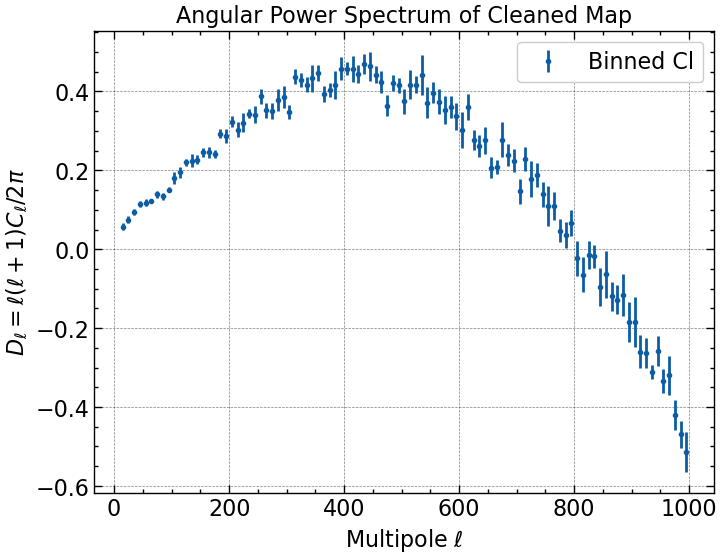

In [105]:
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
#plt.yscale('log')
plt.legend()
plt.title('Angular Power Spectrum of Cleaned Map')

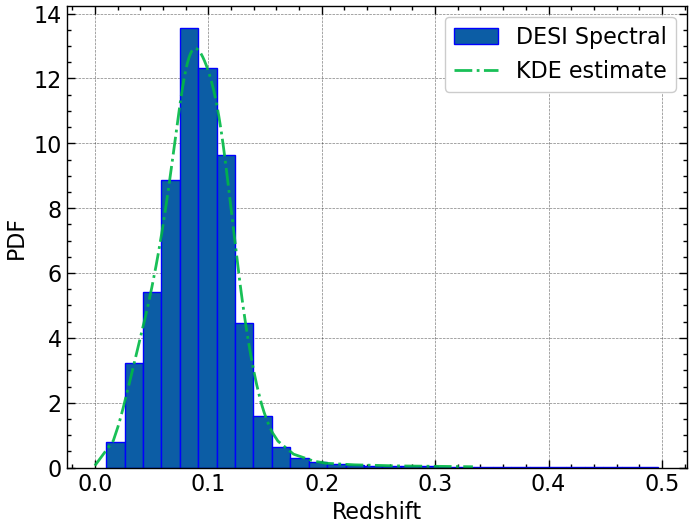

In [106]:
from scipy.stats import gaussian_kde
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(500).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'-.',alpha=0.9,label='KDE estimate')
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.legend()
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)


In [107]:
cosmo = ccl.Cosmology(
    Omega_c=0.25,  # Cold dark matter density
    Omega_b=0.05,  # Baryon density
    h=0.67,        # Hubble parameter
    sigma8=0.8,    # Power spectrum normalization
    n_s=0.96       # Spectral index
)

z=samples_sorted
n_z = y_samples_sorted
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell = np.arange(0, 200)

def dll(a,ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return a*dl 

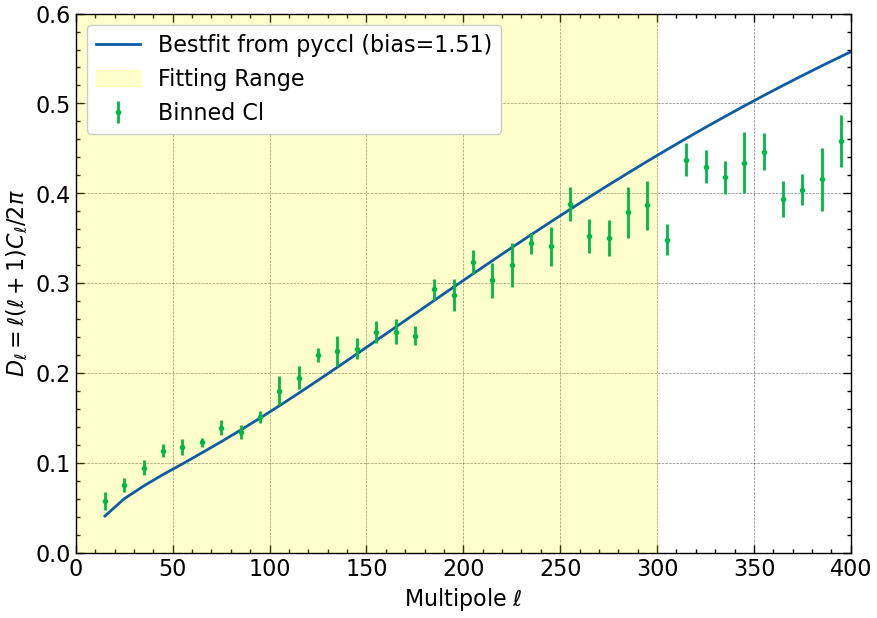

In [130]:
plt.figure(figsize=(10,7))
popt,pcov=cf(dll,bin_centers[bin_centers<300],Cl[bin_centers<300],sigma=dCl[bin_centers<300],p0=[2])


plt.plot(bin_centers,dll(*popt,bin_centers),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlim(0,400)
plt.ylim(0,0.6)
plt.axvspan(0,300,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()



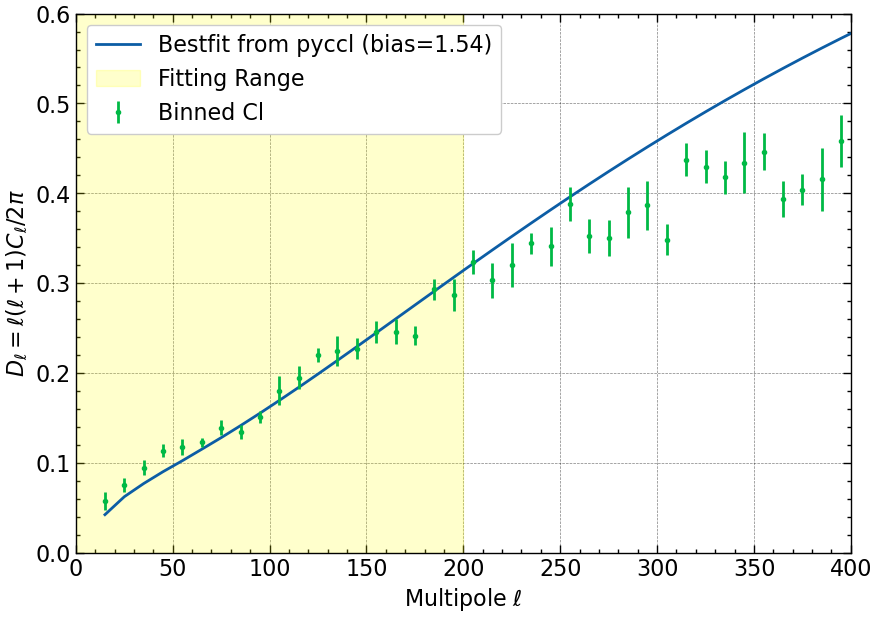

In [131]:
plt.figure(figsize=(10,7))

popt,pcov=cf(dll,bin_centers[bin_centers<200],Cl[bin_centers<200],sigma=dCl[bin_centers<200],p0=[2])


plt.plot(bin_centers,dll(*popt,bin_centers),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlim(0,400)
plt.ylim(0,0.6)
plt.axvspan(0,200,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()

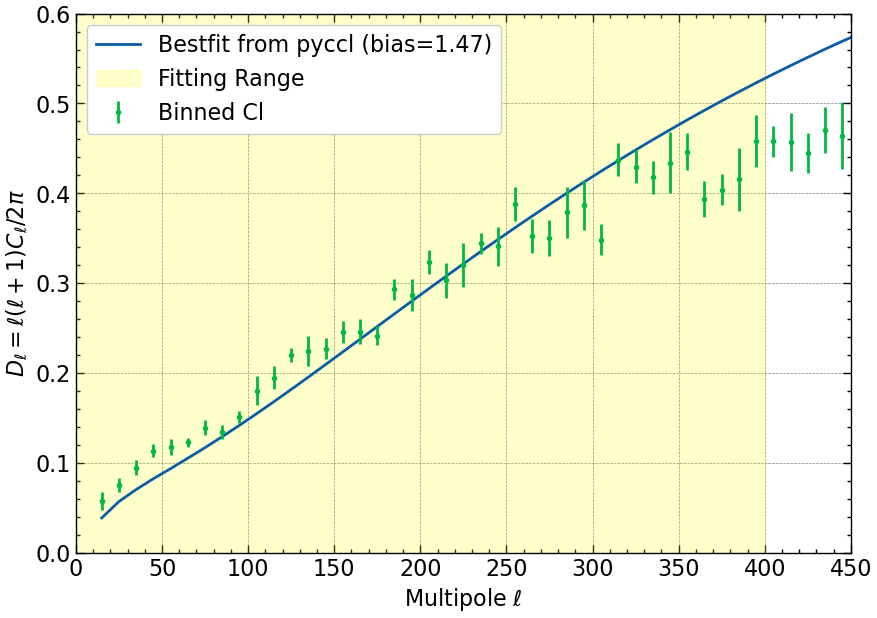

In [133]:
plt.figure(figsize=(10,7))

popt,pcov=cf(dll,bin_centers[bin_centers<400],Cl[bin_centers<400],sigma=dCl[bin_centers<400],p0=[2])


plt.plot(bin_centers,dll(*popt,bin_centers),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlim(0,450)
plt.ylim(0,0.6)
plt.axvspan(0,400,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()